# Step 1: Import Library

In [103]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

import lightgbm as lgb

# Step 2: Load Dataset

In [104]:
train = pd.read_csv("fraud/train.csv")
test = pd.read_csv("fraud/test.csv")

train.head()

,id,time_ind,transac_type,amount,src_acc,src_bal,src_new_bal,dst_acc,dst_bal,dst_new_bal,is_fraud,is_flagged_fraud
0,0,355,CASH_OUT,56964.57,acc4649128,20090.00,0.00,acc8350663,0.00,56964.57,0,0
1,1,284,CASH_OUT,108454.37,acc6660911,505.00,0.00,acc1547749,0.00,108454.37,0,0
2,2,378,NaN,467324.33,acc7810035,1634.00,0.00,acc3033156,258071.61,725395.95,0,0
3,3,129,CASH_IN,274154.97,acc4833344,3171570.20,3445725.17,acc5071405,1692712.58,987166.60,0,0
4,4,217,PAYMENT,NaN,acc8839024,23231.09,0.00,acc6776502,0.00,0.00,0,0


In [105]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5408227 entries, 0 to 5408226
Data columns (total 12 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                int64  
 1   time_ind          int64  
 2   transac_type      object 
 3   amount            float64
 4   src_acc           object 
 5   src_bal           float64
 6   src_new_bal       float64
 7   dst_acc           object 
 8   dst_bal           float64
 9   dst_new_bal       float64
 10  is_fraud          int64  
 11  is_flagged_fraud  int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 495.1+ MB


,id,time_ind,amount,src_bal,src_new_bal,dst_bal,dst_new_bal,is_fraud,is_flagged_fraud
count,5.408227e+06,5.408227e+06,4.705595e+06,5.138428e+06,5.408227e+06,5.138036e+06,5.408227e+06,5.408227e+06,5.408227e+06
mean,2.704113e+06,2.433536e+02,1.535111e+05,8.346354e+05,8.556637e+05,1.100484e+06,1.224941e+06,1.290811e-03,2.958456e-06
std,1.561221e+06,1.423252e+02,5.025534e+05,2.890637e+06,2.925366e+06,3.404143e+06,3.679881e+06,3.590467e-02,1.720014e-03
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.352056e+06,1.550000e+02,1.275030e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.704113e+06,2.390000e+02,6.743566e+04,1.421334e+04,0.000000e+00,1.328216e+05,2.149276e+05,0.000000e+00,0.000000e+00
75%,4.056170e+06,3.350000e+02,1.921993e+05,1.073500e+05,1.442527e+05,9.429581e+05,1.112636e+06,0.000000e+00,0.000000e+00
max,5.408226e+06,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


# Step 3: ตรวจ Missing Values

In [106]:
train.isnull().sum()
test.isnull().sum()

id                       0
time_ind                 0
transac_type        114313
amount              123755
src_acc                  0
src_bal              47687
src_new_bal              0
dst_acc                  0
dst_bal              48076
dst_new_bal              0
is_flagged_fraud         0
dtype: int64

## Step 1 ย่อย: เติม Missing Values

In [107]:
# transac_type (Categorical) เติมด้วย mode
train["transac_type"] = train["transac_type"].fillna(train["transac_type"].mode()[0])
test["transac_type"] = test["transac_type"].fillna(train["transac_type"].mode()[0])

In [108]:
# amount ใช้ median
train["amount"] = train["amount"].fillna(train["amount"].median())
test["amount"] = test["amount"].fillna(train["amount"].median())

In [109]:
# src_bal
train["src_bal"] = train["src_bal"].fillna(0)
test["src_bal"] = test["src_bal"].fillna(0)

In [110]:
# dst_bal
train["dst_bal"] = train["dst_bal"].fillna(0)
test["dst_bal"] = test["dst_bal"].fillna(0)

In [111]:
train["dst_new_bal"] = train["dst_new_bal"].fillna(0)
test["dst_new_bal"] = test["dst_new_bal"].fillna(0)

## Step 2 ย่อย: Encode Transaction Type

In [112]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train["transac_type"] = le.fit_transform(train["transac_type"])
test["transac_type"] = le.transform(test["transac_type"])

## Step 3 ย่อย: ลบ Account ID (สำคัญมาก)

In [113]:
# merchant feature ก่อน
train["dst_is_merchant"] = train["dst_acc"].str.startswith("M").astype(int)
test["dst_is_merchant"] = test["dst_acc"].str.startswith("M").astype(int)

# drop id
train = train.drop(columns=["src_acc","dst_acc"])
test = test.drop(columns=["src_acc","dst_acc"])

## Step 4: Feature Engineering (เพิ่ม score)

In [114]:
# balance change
train["src_diff"] = train["src_bal"] - train["src_new_bal"]
train["dst_diff"] = train["dst_new_bal"] - train["dst_bal"]

test["src_diff"] = test["src_bal"] - test["src_new_bal"]
test["dst_diff"] = test["dst_new_bal"] - test["dst_bal"]

In [115]:
# balance error (fraud indicator)
train["src_error"] = train["src_bal"] - train["amount"] - train["src_new_bal"]
train["dst_error"] = train["dst_bal"] + train["amount"] - train["dst_new_bal"]

test["src_error"] = test["src_bal"] - test["amount"] - test["src_new_bal"]
test["dst_error"] = test["dst_bal"] + test["amount"] - test["dst_new_bal"]

In [116]:
train["amount_ratio_src"] = train["amount"] / (train["src_bal"] + 1)
test["amount_ratio_src"] = test["amount"] / (test["src_bal"] + 1)

train["amount_ratio_dst"] = train["amount"] / (train["dst_bal"] + 1)
test["amount_ratio_dst"] = test["amount"] / (test["dst_bal"] + 1)

train["balance_total"] = train["src_bal"] + train["dst_bal"]
test["balance_total"] = test["src_bal"] + test["dst_bal"]

In [117]:
# transaction type flag
train["is_transfer"] = (train["transac_type"] == 3).astype(int)
test["is_transfer"] = (test["transac_type"] == 3).astype(int)

train["is_cashout"] = (train["transac_type"] == 1).astype(int)
test["is_cashout"] = (test["transac_type"] == 1).astype(int)

In [118]:
train["amount_ratio_src_new"] = train["amount"] / (train["src_new_bal"] + 1)
test["amount_ratio_src_new"] = test["amount"] / (test["src_new_bal"] + 1)

train["amount_ratio_dst_new"] = train["amount"] / (train["dst_new_bal"] + 1)
test["amount_ratio_dst_new"] = test["amount"] / (test["dst_new_bal"] + 1)

In [119]:
train["suspicious_src"] = (train["src_error"].abs() > 1).astype(int)
test["suspicious_src"] = (test["src_error"].abs() > 1).astype(int)

train["suspicious_dst"] = (train["dst_error"].abs() > 1).astype(int)
test["suspicious_dst"] = (test["dst_error"].abs() > 1).astype(int)

In [120]:
train["log_amount"] = np.log1p(train["amount"])
test["log_amount"] = np.log1p(test["amount"])

In [121]:
train["src_new_ratio"] = train["src_new_bal"] / (train["src_bal"] + 1)
test["src_new_ratio"] = test["src_new_bal"] / (test["src_bal"] + 1)

train["dst_new_ratio"] = train["dst_new_bal"] / (train["dst_bal"] + 1)
test["dst_new_ratio"] = test["dst_new_bal"] / (test["dst_bal"] + 1)

In [122]:
train["amount_balance_ratio"] = train["amount"] / (train["balance_total"] + 1)
test["amount_balance_ratio"] = test["amount"] / (test["balance_total"] + 1)

In [123]:
train["zero_src_new"] = (train["src_new_bal"] == 0).astype(int)
test["zero_src_new"] = (test["src_new_bal"] == 0).astype(int)

train["zero_dst_new"] = (train["dst_new_bal"] == 0).astype(int)
test["zero_dst_new"] = (test["dst_new_bal"] == 0).astype(int)

In [124]:
train["abs_src_error"] = train["src_error"].abs()
test["abs_src_error"] = test["src_error"].abs()

train["abs_dst_error"] = train["dst_error"].abs()
test["abs_dst_error"] = test["dst_error"].abs()

In [125]:
train["src_mismatch"] = (train["src_error"] != 0).astype(int)
test["src_mismatch"] = (test["src_error"] != 0).astype(int)

train["dst_mismatch"] = (train["dst_error"] != 0).astype(int)
test["dst_mismatch"] = (test["dst_error"] != 0).astype(int)

In [126]:
train["fraud_rule1"] = (
    (train["is_cashout"]==1) &
    (train["src_new_bal"]==0)
).astype(int)

test["fraud_rule1"] = (
    (test["is_cashout"]==1) &
    (test["src_new_bal"]==0)
).astype(int)

In [127]:
train["overdraft"] = (train["amount"] > train["src_bal"]).astype(int)
test["overdraft"] = (test["amount"] > test["src_bal"]).astype(int)

In [128]:
train["flagged"] = train["is_flagged_fraud"]
test["flagged"] = test["is_flagged_fraud"]

train["flagged_and_transfer"] = (
    (train["is_flagged_fraud"]==1) &
    (train["transac_type"]==3)
).astype(int)

test["flagged_and_transfer"] = (
    (test["is_flagged_fraud"]==1) &
    (test["transac_type"]==3)
).astype(int)

In [129]:
# hour
train["hour"] = train["time_ind"] % 24
test["hour"] = test["time_ind"] % 24

# day
train["day"] = train["time_ind"] // 24
test["day"] = test["time_ind"] // 24

# night transaction
train["is_night"] = train["hour"].isin([0,1,2,3,4]).astype(int)
test["is_night"] = test["hour"].isin([0,1,2,3,4]).astype(int)

In [130]:
train["fraud_rule2"] = (
    (train["transac_type"]==3) &
    (train["amount"]>200000)
).astype(int)

test["fraud_rule2"] = (
    (test["transac_type"]==3) &
    (test["amount"]>200000)
).astype(int)

In [131]:
train["balance_consistency"] = (
    (train["src_bal"] - train["amount"] - train["src_new_bal"]).abs()
)

test["balance_consistency"] = (
    (test["src_bal"] - test["amount"] - test["src_new_bal"]).abs()
)

In [132]:
train["is_transfer_zero"] = (
    (train["transac_type"]==3) &
    (train["src_new_bal"]==0)
).astype(int)

test["is_transfer_zero"] = (
    (test["transac_type"]==3) &
    (test["src_new_bal"]==0)
).astype(int)

In [133]:
train["large_transfer"] = (
    (train["transac_type"]==3) &
    (train["amount"]>500000)
).astype(int)

test["large_transfer"] = (
    (test["transac_type"]==3) &
    (test["amount"]>500000)
).astype(int)

In [134]:
# Fraud มักโอน เงินหมดบัญชี
train["full_drain"] = (
(train["src_bal"] == train["amount"]) &
(train["src_new_bal"] == 0)
).astype(int)

test["full_drain"] = (
(test["src_bal"] == test["amount"]) &
(test["src_new_bal"] == 0)
).astype(int)

In [135]:
# Fraud มักมี balance mismatch
train["src_balance_error"] = (
    train["src_bal"] - train["amount"] - train["src_new_bal"]
)

test["src_balance_error"] = (
    test["src_bal"] - test["amount"] - test["src_new_bal"]
)

train["dst_balance_error"] = (
    train["dst_bal"] + train["amount"] - train["dst_new_bal"]
)

test["dst_balance_error"] = (
    test["dst_bal"] + test["amount"] - test["dst_new_bal"]
)

In [136]:
#ธุรกรรมที่ใหญ่ผิดปกติ
threshold = train["amount"].quantile(0.99)

train["large_txn"] = (train["amount"] > threshold).astype(int)
test["large_txn"] = (test["amount"] > threshold).astype(int)

## Step 5: Split Data

In [137]:
# from sklearn.model_selection import train_test_split

# X = train.drop(columns=["is_fraud","id"])
# y = train["is_fraud"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

In [138]:
# Step 5: Prepare data
# X = train.drop(columns=["is_fraud","id"])
y = train["is_fraud"]
X = train.drop(columns=["is_fraud","id","time_ind"])
X_test = test.drop(columns=["id","time_ind"])

# X_test = test.drop(columns=["id"])

from sklearn.model_selection import StratifiedKFold

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

## Step 6: Train Model (LightGBM)

In [139]:
# import lightgbm as lgb

# # model = lgb.LGBMClassifier(
# #     n_estimators=2000,
# #     learning_rate=0.02,
# #     num_leaves=128,
# #     max_depth=10,
# #     scale_pos_weight=773,
# #     random_state=42
# # )

# model = lgb.LGBMClassifier(
#     n_estimators=4000,
#     learning_rate=0.01,
#     num_leaves=256,
#     max_depth=-1,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight=773,
#     random_state=42
# )

# model.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_val, y_val)],
#     eval_metric="binary_logloss",
#     callbacks=[lgb.early_stopping(100)]
# )

In [140]:
# for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):

#     print("Fold:", fold+1)

#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     model = lgb.LGBMClassifier(
#         n_estimators=5000,
#         learning_rate=0.01,
#         num_leaves=256,
#         max_depth=-1,
#         min_child_samples=50,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         reg_alpha=0.1,
#         reg_lambda=0.1,
#         scale_pos_weight=773,
#         random_state=42
#     )

#     model.fit(
#         X_train,
#         y_train,
#         eval_set=[(X_val, y_val)],
#         eval_metric="binary_logloss",
#         callbacks=[lgb.early_stopping(100)],
#     )

#     oof_preds[val_idx] = model.predict_proba(X_val)[:,1]

#     test_preds += model.predict_proba(X_test)[:,1] / folds.n_splits

In [147]:
for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):

    print("Fold:", fold+1)

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(

    n_estimators=3000,
    learning_rate=0.005,
    num_leaves=256,
    max_depth=-1,

    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,

    reg_alpha=0.5,
    reg_lambda=0.5,

    scale_pos_weight=773,

    random_state=42,

    n_jobs=-1
)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="binary_logloss",
        callbacks=[lgb.early_stopping(100)],
    )

    oof_preds[val_idx] = model.predict_proba(X_val)[:,1]

    test_preds += model.predict_proba(X_test)[:,1] / folds.n_splits

Fold: 1
[LightGBM] [Info] Number of positive: 5585, number of negative: 4320996
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.398252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5957
[LightGBM] [Info] Number of data points in the train set: 4326581, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651157
[LightGBM] [Info] Start training from score -6.651157
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [148]:
import xgboost as xgb
print(xgb.__version__)

3.1.2


In [149]:
import torch
print(torch.cuda.is_available())

True


In [150]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=773,

    device="cuda",
    tree_method="hist"
)

In [151]:
xgb_preds = np.zeros(len(train))
xgb_test_preds = np.zeros(len(test))

for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):

    print("XGB Fold:", fold+1)

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_model.fit(X_train, y_train)

    xgb_preds[val_idx] = xgb_model.predict_proba(X_val)[:,1]

    xgb_test_preds += xgb_model.predict_proba(X_test)[:,1] / folds.n_splits

XGB Fold: 1


c:\Users\Admin\Desktop\ProjectML\swin_env\lib\site-packages\xgboost\core.py:774: UserWarning: [00:47:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGB Fold: 2
XGB Fold: 3
XGB Fold: 4
XGB Fold: 5


In [152]:
final_oof = (oof_preds + xgb_preds) / 2
final_test = (test_preds + xgb_test_preds) / 2

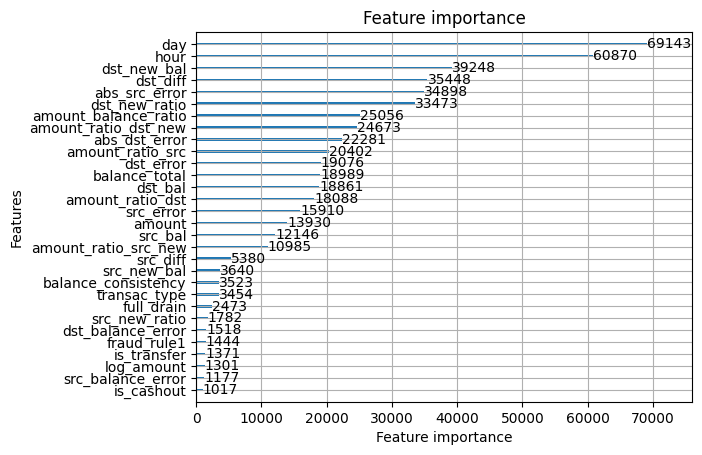

In [153]:
import matplotlib.pyplot as plt

lgb.plot_importance(model, max_num_features=30)
plt.show()

## Step 7: Evaluate

In [ ]:
# from sklearn.metrics import f1_score

# pred = model.predict(X_val)

# print("F1 Macro:", f1_score(y_val, pred, average="macro"))

In [ ]:
# from sklearn.metrics import f1_score
# import numpy as np

# probs = model.predict_proba(X_val)[:,1]

# best_threshold = 0
# best_f1 = 0

# for t in np.arange(0.001,0.5,0.001):
#     preds = (probs > t).astype(int)
#     f1 = f1_score(y_val, preds, average='macro')

#     if f1 > best_f1:
#         best_f1 = f1
#         best_threshold = t

# print("Best threshold:", best_threshold)
# print("Best F1:", best_f1)

In [ ]:
# from sklearn.metrics import f1_score

# best_threshold = 0
# best_f1 = 0

# for t in np.arange(0.001,0.5,0.001):

#     preds = (oof_preds > t).astype(int)

#     f1 = f1_score(y, preds, average="macro")

#     if f1 > best_f1:
#         best_f1 = f1
#         best_threshold = t

# print("Best threshold:", best_threshold)
# print("Best F1:", best_f1)

Best threshold: 0.495
Best F1: 0.9713112923380609


In [154]:
from sklearn.metrics import f1_score

best_threshold = 0
best_f1 = 0

for t in np.arange(0.001,0.5,0.001):

    preds = (final_oof > t).astype(int)

    f1 = f1_score(y, preds, average="macro")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.499
Best F1: 0.9793823288358607


## Step 8: Predict Test

In [155]:
# pred_prob = model.predict_proba(X_test)[:,1]

# pred_test = (pred_prob > 0.02).astype(int)
# pred_test = (pred_prob > best_threshold).astype(int)
# pred_test = (test_preds > best_threshold).astype(int)
pred_test = (final_test > best_threshold).astype(int)

## Step 9: Submission

In [156]:
submission = pd.DataFrame({
    "id": test["id"],
    "is_fraud": pred_test
})

submission.to_csv("submission4.csv", index=False)

In [157]:
print(test.shape)
print(pred_test.shape)
print(submission.shape)

print(len(pred_test))
print(len(submission))

(954393, 48)
(954393,)
(954393, 2)
954393
954393


In [158]:
train["is_fraud"].value_counts()

is_fraud
0    5401246
1       6981
Name: count, dtype: int64

In [159]:
train["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [160]:
# print(pred_prob[:20])
# print(pred_prob.max())

print(test_preds[:20])
print(test_preds.max())

[4.44364643e-07 2.72363649e-07 1.75671261e-07 2.86668410e-07
 2.19212893e-07 7.25365003e-08 1.36695094e-07 1.28095519e-07
 4.79824043e-07 2.44327282e-06 1.61968644e-07 6.13286476e-07
 1.07179221e-06 6.11967535e-07 3.24344640e-07 1.21330161e-07
 3.21457248e-07 3.12435762e-07 2.30488395e-06 2.69721659e-07]
0.9999916528495065


In [161]:
np.unique(pred_test, return_counts=True)

(array([0, 1]), array([953151,   1242]))

In [162]:
submission["is_fraud"].value_counts()

is_fraud
0    953151
1      1242
Name: count, dtype: int64

In [163]:
submission[submission["is_fraud"]==1].head()

,id,is_fraud
2399,5410626,1
3036,5411263,1
3411,5411638,1
4976,5413203,1
5365,5413592,1
